# Using YOLO to Detect Objects


#### Set up the Environment

In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image, ImageFont, ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle

In [8]:
_MODEL_SIZE = (416, 416)

#### Load YOLO Model and Weights
Download pre-trained YOLO weights (YOLOv3).
Load the model architecture and weights using TensorFlow/Keras.

In [9]:
# Load the model
model = load_model('./coco_yolo3.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [10]:
model.summary()

Model: "model_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_3             │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_0 (Conv2D)     │ (None, None,      │        864 │ input_3[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bnorm_0             │ (None, None,      │        128 │ conv_0[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_0 (LeakyReLU) │ (None, None,      │          0 │ bnorm_0[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_10   │ (None, None,      │          0 │ leaky_0[0][0]     │
│ (ZeroPadding2D)     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, None,      │     18,432 │ zero_padding2d_1… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bnorm_1             │ (None, None,      │        256 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_1 (LeakyReLU) │ (None, None,      │          0 │ bnorm_1[0][0]     │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, None,      │      2,048 │ leaky_1[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bnorm_2             │ (None, None,      │        128 │ conv_2[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_2 (LeakyReLU) │ (None, None,      │          0 │ bnorm_2[0][0]     │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv2D)     │ (None, None,      │     18,432 │ leaky_2[0][0]     │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bnorm_3             │ (None, None,      │        256 │ conv_3[0][0]      │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_3 (LeakyReLU) │ (None, None,      │          0 │ bnorm_3[0][0]     │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_46 (Add)        │ (None, None,      │          0 │ leaky_1[0][0],    │
│                     │ None, 64)         │            │ leaky_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_11   │ (None, None,      │          0 │ add_46[0][0]      │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv2D)     │ (None, None,      │     73,728 │ zero_padding2d_1

 Total params: 62,001,757 (236.52 MB)

 Trainable params: 61,949,149 (236.32 MB)

 Non-trainable params: 52,608 (205.50 KB)

In [11]:
# Labels for the COCO dataset
class_names = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', \
          'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', \
          'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', \
          'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', \
          'ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', \
          'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', \
          'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', \
          'chair', 'sofa', 'potted plant', 'bed', 'dining table', 'toilet', 'tv monitor', 'laptop', 'mouse', \
          'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', \
          'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

#### Preprocess the Image
*   Load the image using PIL.
*   Resize the image to the input size expected by the YOLO model (e.g. 416x416).
*   Normalize pixel values.



In [12]:
def preprocess_image(image, target_size=_MODEL_SIZE):
  image_processed = image.convert('RGB')  # Add this line to convert to RGB
  image_processed = image_processed.resize(size=target_size)
  image_processed = np.array(image_processed, dtype=np.float32) / 255.0
  #image_processed = np.array(image_processed, dtype=np.float32)
  image_processed = np.expand_dims(image_processed, axis=0)
  return image_processed

#### Make Predictions
*   Pass the preprocessed image through the YOLO model.


In [13]:
def detect_objects(image, model, class_names=class_names, confidence_threshold=0.5):
  image_processed = preprocess_image(image)
  predictions = model.predict(image_processed)

  return predictions

Utilities for Interpeting YOLO Predictions

In [14]:
class BoundBox:
    def __init__(self, xmin, ymin, xmax, ymax, objness = None, classes = None):
        self.xmin = xmin
        self.ymin = ymin
        self.xmax = xmax
        self.ymax = ymax

        self.objness = objness
        self.classes = classes

        self.label = -1
        self.score = -1

    def get_label(self):
        if self.label == -1:
            self.label = np.argmax(self.classes)

        return self.label

    def get_score(self):
        if self.score == -1:
            self.score = self.classes[self.get_label()]

        return self.score

def _sigmoid(x):
    return 1. / (1. + np.exp(-x))

def _decode_netout(netout, anchors, obj_thresh, net_h, net_w):
    netout_c = netout.copy() # Preserve original prediction data
    grid_h, grid_w = netout_c.shape[:2]
    nb_box = 3
    netout_r = netout_c.reshape((grid_h, grid_w, nb_box, -1))
    nb_class = netout_r.shape[-1] - 5

    boxes = []

    netout_r[..., :2]  = _sigmoid(netout_r[..., :2])
    netout_r[..., 4:]  = _sigmoid(netout_r[..., 4:])
    netout_r[..., 5:]  = netout_r[..., 4][..., np.newaxis] * netout_r[..., 5:]
    netout_r[..., 5:] *= netout_r[..., 5:] > obj_thresh

    for i in range(grid_h*grid_w):
        row = i / grid_w
        col = i % grid_w

        for b in range(nb_box):
            # 4th element is objectness score
            objectness = netout_r[int(row)][int(col)][b][4]

            if(objectness.all() <= obj_thresh): continue

            # first 4 elements are x, y, w, and h
            x, y, w, h = netout_r[int(row)][int(col)][b][:4]

            x = (col + x) / grid_w # center position, unit: image width
            y = (row + y) / grid_h # center position, unit: image height
            w = anchors[2 * b + 0] * np.exp(w) / net_w # unit: image width
            h = anchors[2 * b + 1] * np.exp(h) / net_h # unit: image height

            # last elements are class probabilities
            classes = netout_r[int(row)][col][b][5:]
            box = BoundBox(x-w/2, y-h/2, x+w/2, y+h/2, objectness, classes)
            boxes.append(box)

    return boxes

def _interval_overlap(interval_a, interval_b):
    x1, x2 = interval_a
    x3, x4 = interval_b

    if x3 < x1:
        if x4 < x1:
            return 0
        else:
            return min(x2,x4) - x1
    else:
        if x2 < x3:
             return 0
        else:
            return min(x2,x4) - x3

def _sigmoid(x):
    return 1. / (1. + np.exp(-x))

def _bbox_iou(box1, box2):
    intersect_w = _interval_overlap([box1.xmin, box1.xmax], [box2.xmin, box2.xmax])
    intersect_h = _interval_overlap([box1.ymin, box1.ymax], [box2.ymin, box2.ymax])
    intersect = intersect_w * intersect_h

    w1, h1 = box1.xmax-box1.xmin, box1.ymax-box1.ymin
    w2, h2 = box2.xmax-box2.xmin, box2.ymax-box2.ymin

    union = w1*h1 + w2*h2 - intersect

    return float(intersect) / union

def _correct_yolo_boxes(boxes, image_h, image_w):
    for box in boxes:
        box.xmin = int(box.xmin * image_w)
        box.xmax = int(box.xmax * image_w)
        box.ymin = int(box.ymin * image_h)
        box.ymax = int(box.ymax * image_h)

def _do_nms(boxes, nms_thresh):
    if len(boxes) > 0:
        nb_class = len(boxes[0].classes)
    else:
        return

    for c in range(nb_class):
        sorted_indices = np.argsort([-box.classes[c] for box in boxes])

        for i in range(len(sorted_indices)):
            index_i = sorted_indices[i]

            if boxes[index_i].classes[c] == 0: continue

            for j in range(i+1, len(sorted_indices)):
                index_j = sorted_indices[j]

                if _bbox_iou(boxes[index_i], boxes[index_j]) >= nms_thresh:
                    boxes[index_j].classes[c] = 0



Intepret the model predictions

In [15]:
def decode_predictions(predictions, image_w, image_h, min_score=0.9, input_w=_MODEL_SIZE[0], input_h=_MODEL_SIZE[1], class_names=class_names):
    boxes, output = [], []
    # Anchors: See https://github.com/shahkaran76/yolo_v3-tensorflow-ipynb/blob/master/YOLO%20Tensorflow.ipynb
    anchors = [[116,90, 156,198, 373,326],  [30,61, 62,45, 59,119], [10,13, 16,30, 33,23]]

    for i in range(len(predictions)):
        boxes += _decode_netout(predictions[i][0], anchors[i], min_score, input_h, input_w)

    _correct_yolo_boxes(boxes, image_h, image_w)
    _do_nms(boxes, 0.45) # NMS threshold = 0.45

    for box in boxes:
        for i in range(len(class_names)):
            if box.classes[i] > min_score:
                box.label = class_names[i]
                box.score = box.classes[i]
                output.append(box)

    return output

#### Visualize Results:
*   Draw bounding boxes and class labels on the original image.
*   Display the annotated image in the Jupyter Notebook.



In [16]:
def draw_boxes(image, boxes, figsize=(12, 8)):
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'xticks': [], 'yticks': []})
    ax.imshow(image)

    for box in boxes:
        color = np.random.permutation([np.random.rand(), 1, 0])
        y1, x1, y2, x2 = box.ymin, box.xmin, box.ymax, box.xmax
        width, height = x2 - x1, y2 - y1
        rect = Rectangle((x1, y1), width, height, fill=False, color=color, lw=2)
        ax.add_patch(rect)
        label = f'{box.label} ({box.score:.0%})'
        ax.text(x1 + (width / 2), y1, label, color='black', backgroundcolor=color, ha='center', va='bottom', fontweight='bold', bbox=dict(color=color))

Detect Objects Example

(370, 340)


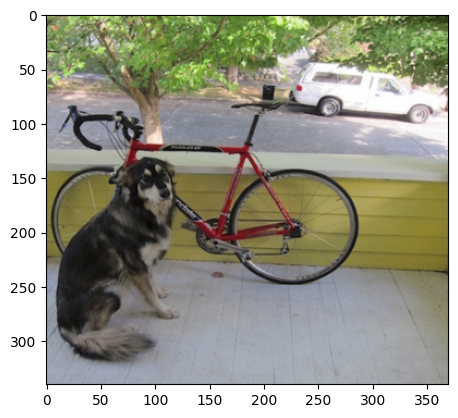

In [17]:
image_path = './dog-bike.png'
image = Image.open(image_path)
print(image.size)
plt.imshow(image)
plt.show()

In [18]:
detections = detect_objects(image, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [19]:
boxes = decode_predictions(detections, image.size[0], image.size[1], min_score=0.98)
for box in boxes:
  print(f'({box.xmin}, {box.ymin}), ({box.xmax}, {box.ymax}), {box.label}, {box.score} ')

(0, 82), (300, 271), bicycle, 0.9930422306060791 
(11, 137), (126, 323), dog, 0.9989123940467834 


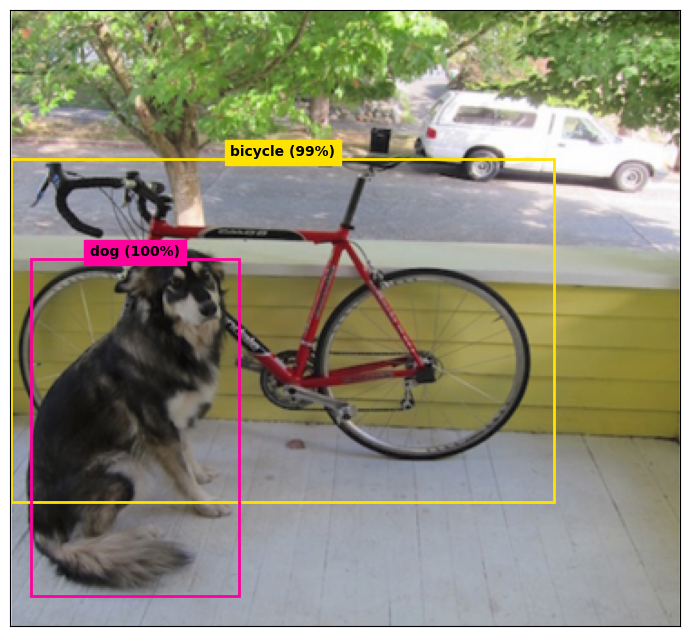

In [20]:
image_with_boxes = draw_boxes(image, boxes)

Your Turn
* Detect Objects for FLC_library.jpg
* Use a min_score of 95%

In [ ]:
# Detect Objects for FLC_library.jpg

(940, 529)


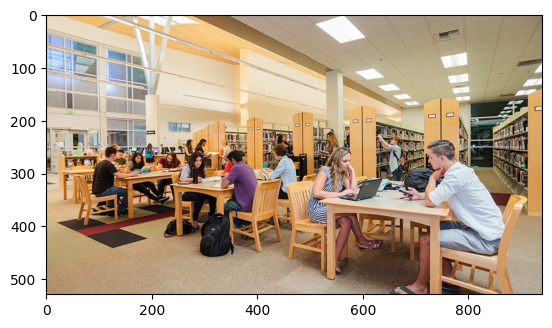

In [21]:
image2_path = './FLC_library.jpg'
image2 = Image.open(image2_path)
print(image2.size)
plt.imshow(image2)
plt.show()

In [22]:
detections = detect_objects(image2, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step


In [23]:
boxes = decode_predictions(detections, image2.size[0], image2.size[1], min_score=0.95)
for box in boxes:
  print(f'({box.xmin}, {box.ymin}), ({box.xmax}, {box.ymax}), {box.label}, {box.score} ')

(670, 264), (870, 544), person, 0.9972221851348877 
(636, 245), (681, 328), person, 0.9628185033798218 
(416, 254), (472, 358), person, 0.9829896688461304 
(340, 318), (444, 458), chair, 0.9923737049102783 
(749, 363), (923, 544), chair, 0.9549734592437744 
(565, 316), (641, 360), laptop, 0.9770968556404114 


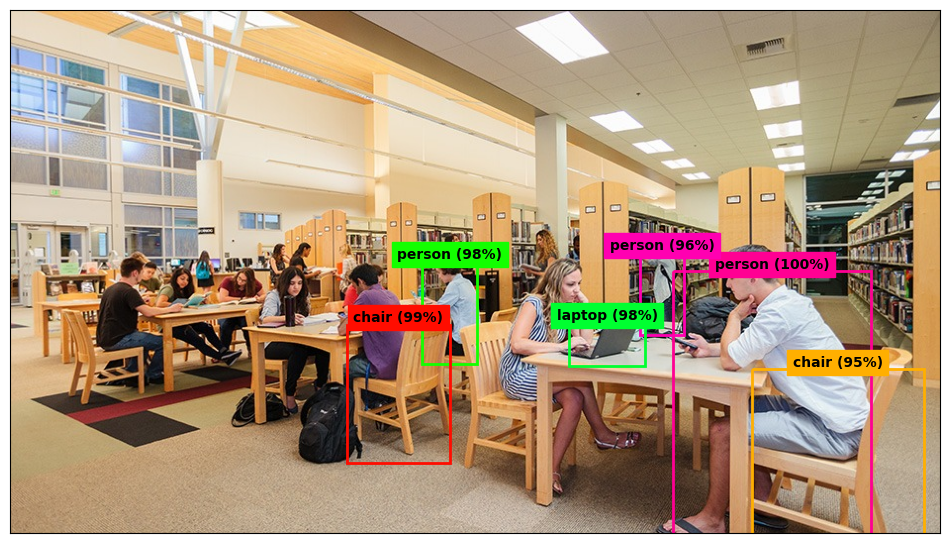

In [24]:
image_with_boxes = draw_boxes(image2, boxes)

Sources:
*   https://www.atmosera.com/blog/object-detection/
*   https://github.com/jeffprosise/Deep-Learning/blob/master/Object%20Detection%20(YOLO).ipynb
*   https://github.com/jeffprosise/Deep-Learning/blob/master/yolo3.py
*   https://github.com/shahkaran76/yolo_v3-tensorflow-ipynb
*   Google AI results for 'jupyter notebook yolo tensorflow image'